In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("student_performance_updated_1000.csv")

print(df.head())
print(df.info())
print(df.describe())

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                False  
1          2.2            70.0  

In [4]:
print(df.isnull().sum())

StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


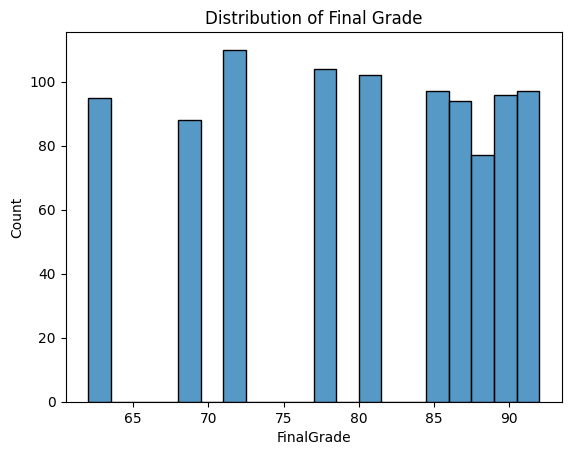

In [6]:
sns.histplot(df['FinalGrade'], bins=20)
plt.title("Distribution of Final Grade")
plt.show()

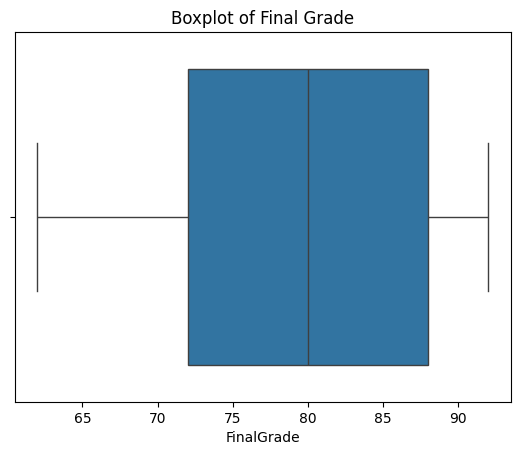

In [7]:
sns.boxplot(x=df['FinalGrade'])
plt.title("Boxplot of Final Grade")
plt.show()

In [11]:
def performance(Grade):

    if Grade < 40:
        return "Low"

    elif Grade < 70:
        return "Medium"

    else:
        return "High"

df['Performance'] = df['FinalGrade'].apply(performance)

print(df[['FinalGrade','Performance']].head())

   FinalGrade Performance
0        80.0        High
1        87.0        High
2        68.0      Medium
3        92.0        High
4        85.0        High


In [12]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
print(df.columns)

Index(['StudentID', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)', 'Name_Aaron Walls', 'Name_Abigail Ingram',
       ...
       'Name_William Weber', 'Name_William White', 'Name_Yolanda Chen',
       'Name_Yvonne Krueger', 'Name_Zachary Daniel', 'Gender_Male',
       'ParentalSupport_Low', 'ParentalSupport_Medium',
       'Online Classes Taken_True', 'Performance_Medium'],
      dtype='object', length=974)


In [17]:
def performance(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df['Performance'] = df['FinalGrade'].apply(performance)

In [18]:
df = pd.get_dummies(df, columns=['Performance'])

In [19]:
print(df.columns)

Index(['StudentID', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)', 'Name_Aaron Walls', 'Name_Abigail Ingram',
       ...
       'Name_Yolanda Chen', 'Name_Yvonne Krueger', 'Name_Zachary Daniel',
       'Gender_Male', 'ParentalSupport_Low', 'ParentalSupport_Medium',
       'Online Classes Taken_True', 'Performance_Medium', 'Performance_High',
       'Performance_Medium'],
      dtype='object', length=976)


In [21]:
def performance(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df['Performance'] = df['FinalGrade'].apply(performance)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Performance_Label'] = le.fit_transform(df['Performance'])

In [23]:
X = df.drop(['FinalGrade','Performance','Performance_Label'], axis=1)

y = df['Performance_Label']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
df = df.dropna()

In [27]:
X = df.drop(['FinalGrade','Performance','Performance_Label'], axis=1)

y = df['Performance_Label']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [31]:
df = df.fillna(df.mean(numeric_only=True))

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


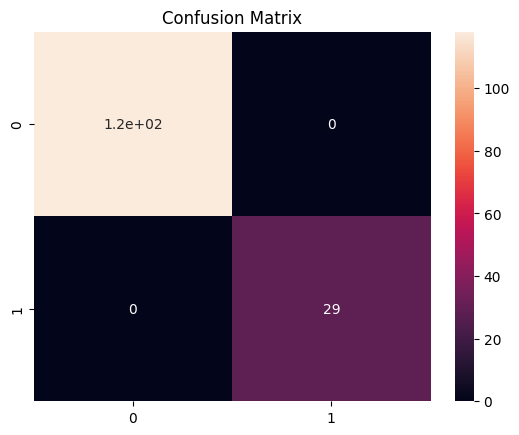

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.show()

In [36]:
X = df.drop(['FinalGrade','Performance','Performance_Label'], axis=1)

y = df['FinalGrade']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = reg.predict(X_test)

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.07139682140629455
MAE: 7.633319390996029
MSE: 87.77704376080747


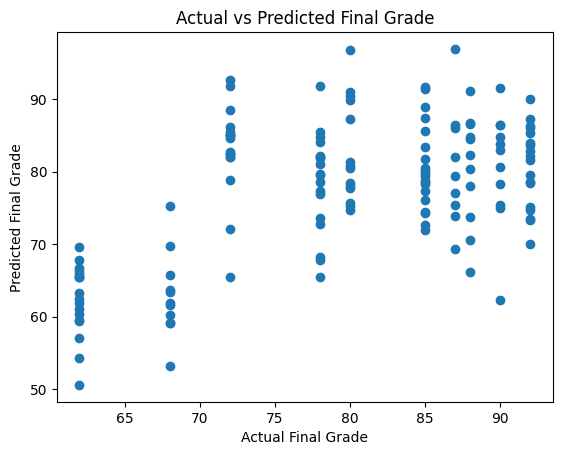

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.title("Actual vs Predicted Final Grade")

plt.show()

Dataset Preview
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                False  
1          2.2  

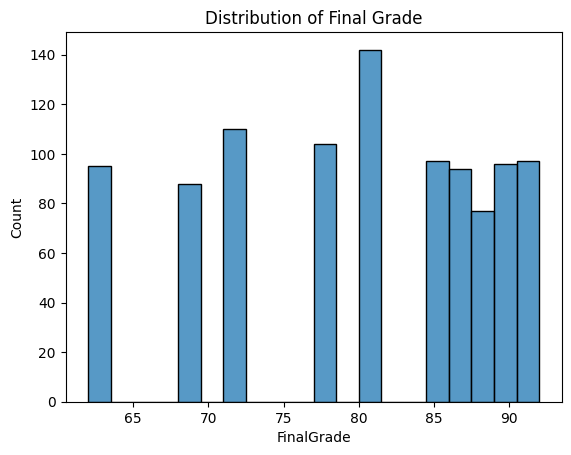

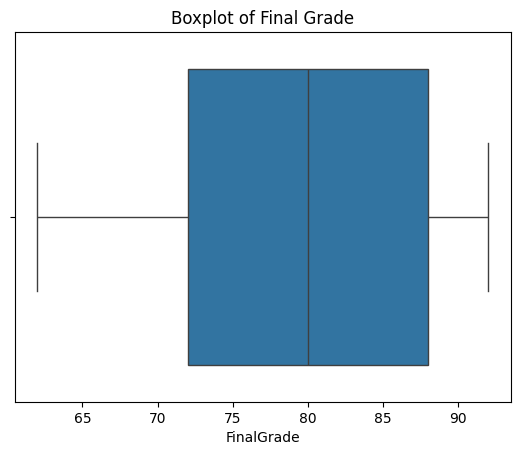

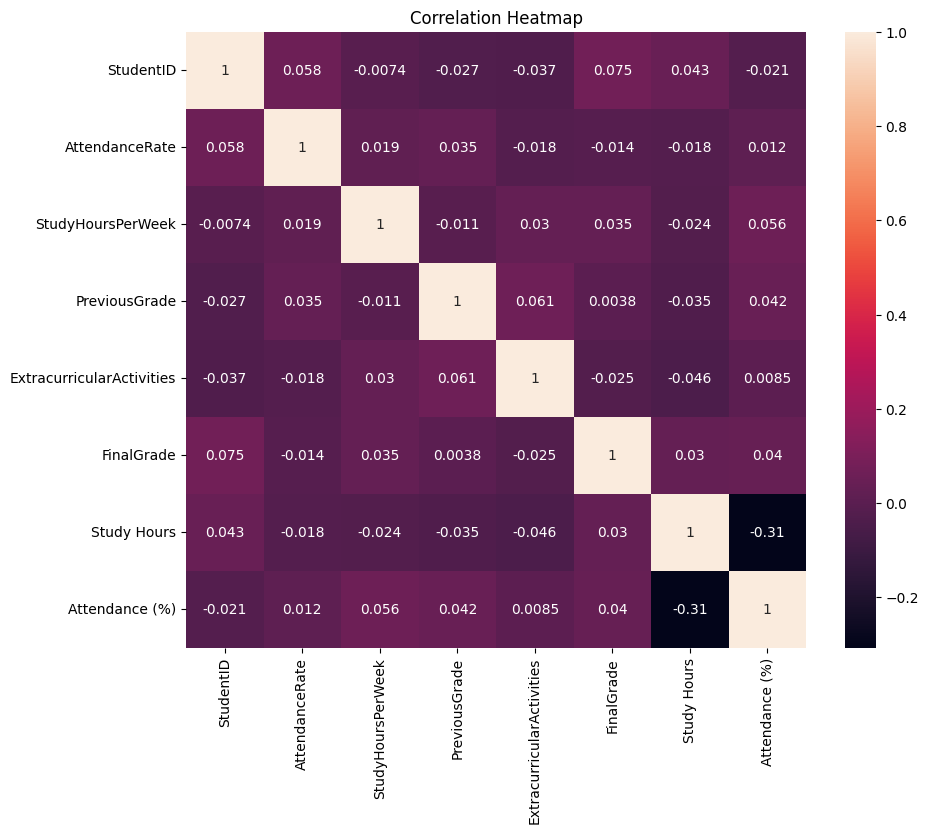


Classification Accuracy: 0.8


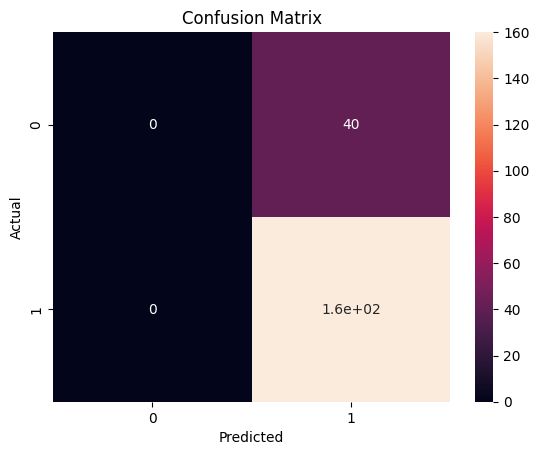


Regression Results
R2 Score: 0.012217870936644615
MAE: 7.998960068557171
MSE: 88.69724023628318


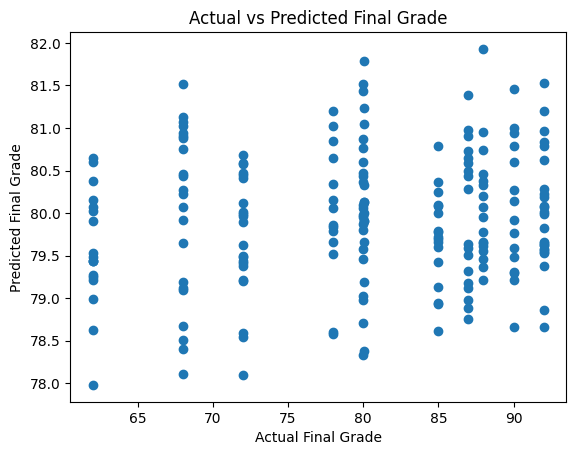


Example Predicted Final Grade: [78.93517517]


In [43]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv("student_performance_updated_1000.csv")

print("Dataset Preview")
print(df.head())

print("\nColumns in Dataset")
print(df.columns)


# ==========================================
# 3. Keep Only Numeric Columns
# (removes names and other text columns)
# ==========================================

df = df.select_dtypes(include=np.number)


# ==========================================
# 4. Handle Missing Values
# ==========================================

df = df.fillna(df.mean())


# ==========================================
# 5. Exploratory Data Analysis
# ==========================================

# Distribution Plot
plt.figure()
sns.histplot(df['FinalGrade'], bins=20)
plt.title("Distribution of Final Grade")
plt.show()

# Box Plot
plt.figure()
sns.boxplot(x=df['FinalGrade'])
plt.title("Boxplot of Final Grade")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


# ==========================================
# 6. Create Performance Category
# ==========================================

def performance(score):

    if score < 40:
        return 0    # Low

    elif score < 70:
        return 1    # Medium

    else:
        return 2    # High


df['Performance'] = df['FinalGrade'].apply(performance)


# ==========================================
# 7. Multinomial Classification
# Logistic Regression
# ==========================================

X = df.drop(['FinalGrade','Performance'], axis=1)

y = df['Performance']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


# ==========================================
# 8. Classification Evaluation
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nClassification Accuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ==========================================
# 9. Linear Regression
# Predict FinalGrade
# ==========================================

X_reg = df.drop(['FinalGrade','Performance'], axis=1)

y_reg = df['FinalGrade']


X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


reg = LinearRegression()

reg.fit(X_train, y_train)


y_pred_reg = reg.predict(X_test)


# ==========================================
# 10. Regression Evaluation
# ==========================================

print("\nRegression Results")

print("R2 Score:", r2_score(y_test, y_pred_reg))

print("MAE:", mean_absolute_error(y_test, y_pred_reg))

print("MSE:", mean_squared_error(y_test, y_pred_reg))


# ==========================================
# 11. Actual vs Predicted Plot
# ==========================================

plt.figure()

plt.scatter(y_test, y_pred_reg)

plt.xlabel("Actual Final Grade")

plt.ylabel("Predicted Final Grade")

plt.title("Actual vs Predicted Final Grade")

plt.show()


# ==========================================
# 12. Example Prediction
# ==========================================

sample = X_reg.iloc[0:1]

prediction = reg.predict(sample)

print("\nExample Predicted Final Grade:", prediction)